# Objectif du notebook 

Date de création : 03/05/2026

Illustration des performances de l'estimateur CS-EVD par comparaison à l'estimation obtenu par déconvolution à l'aide d'un filtre de Wiener. 

L'étude est menée sur la séquence d'émission 144 restreinte aux émissions le long de la fibre. La gamme de fréquence est limitée à la gamme de fréquence $[400, 800]~\text{Hz}$ centrée sur la résonance de la source. 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
print(project_root)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

c:\Users\baptiste.menetrier\Desktop\devPy\phd


In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°40 à n°180).

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load bathy data 
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (40, 180)     # Only between OBS1 and OBS3
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [6]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 144:
	Number of pulses: 141
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


# Étape 2 : calcul du vecteur de RTFs
Le vecteur de RTF est estimé pour chaque position de la source à l'aide de la méthode CS-EVD et par déconvolution. 

## Définition des paramètres du processeur

In [7]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 8.1,
    "alpha_overlap": 0.95,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [8]:
print(rtf_mfp_processor.fsm_nperseg, rtf_mfp_processor.fsm_noverlap)
# fsm_active nperseg and noverlap are only updated when we run the processor
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
print(2**13)

16384 15564
4096 2048
8192


## Calcul des RTFs

In [9]:
###########################
# Library
###########################
# id_library = 100

# active_replicas_args = {
#     "replica_sequence_ids": [144],
#     "replica_pulse_slice": [pulse_slice],
#     "load_precomputed_feature": False,
# }
# passive_replicas_args = {
#     "start_datetimes": [],
#     "end_datetimes": [],
#     "load_precomputed_feature": False,
# }

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )

###########################
# Event
###########################
id_event = 100

target_mmsi = None
active_feature_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_feature_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_event(
#     active_feature_args=active_feature_args,
#     passive_feature_args=passive_feature_args,
#     id=id_event,
#     target_mmsi=target_mmsi,
# )

In [10]:
# print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
# print(2**13)

# Print properties
seq_id = 144
df_seq_i = df_arr.loc[df_arr["sequence_id"] == seq_id]

print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq_i['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq_i['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq_i['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq_i['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq_i['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq_i['repeat_period_s'].iloc[0]} seconds")
print(f"\tSource depth: {df_seq_i['deployed_length_m'].iloc[0]} meters")

Signal properties for sequence 144:
	Number of pulses: 500
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds
	Source depth: 18 meters


In [11]:
# ###########################
# # Event
# ###########################
# id_event = 100

# # # 4V, 5m
# # selected_static_sequences = [
# #     155,
# #     116,
# #     131,
# # ]

# # # 4V, 2m
# # selected_static_sequences = [
# #     151,
# #     116,    # 5m no 2m
# #     127,
# # ]

# # 4V, 8m
# selected_static_sequences = [
#     167,
#     116,    # 5m no 8m
#     143,
# ]


# # Print properties
# for seq_id in selected_static_sequences:
#     df_seq_i = df_arr.loc[df_arr["sequence_id"] == seq_id]

#     print(f"Signal properties for sequence {seq_id}:")
#     print(f"\tNumber of pulses: {len(df_seq_i['pulse_id'].unique())}")
#     print(f"\tSignal type: {df_seq_i['signal_type'].iloc[0]}")
#     print(f"\tMinimum frequency: {df_seq_i['frequency_min_hz'].iloc[0]} Hz")
#     print(f"\tMaximum frequency: {df_seq_i['frequency_max_hz'].iloc[0]} Hz")
#     print(f"\tSignal duration: {df_seq_i['duration_s'].iloc[0]} seconds")
#     print(f"\tRepeat period: {df_seq_i['repeat_period_s'].iloc[0]} seconds")
#     print(f"\tSource depth: {df_seq_i['deployed_length_m'].iloc[0]} meters")

# target_mmsi = None
# active_feature_args = {
#     "replica_sequence_ids": selected_static_sequences,
#     "load_precomputed_feature": False,
# }
# passive_feature_args = {
#     "start_datetimes": [],
#     "end_datetimes": [],
#     "load_precomputed_feature": False,
# }

# rtf_mfp_processor.compute_event(
#     active_feature_args=active_feature_args,
#     passive_feature_args=passive_feature_args,
#     id=id_event,
#     target_mmsi=target_mmsi,
# )


###########################
# Library
###########################
id_library = 100

# # 4V, 5m
selected_static_sequences = [
    155,
    116,
    131,
]

# # 4V, 2m
# selected_static_sequences = [
#     151,
#     116,    # 5m no 2m
#     127,
# ]

# # 4V, 8m
# selected_static_sequences = [
#     167,
#     116,  # 5m no 8m
#     143,
# ]

# Print properties
for seq_id in selected_static_sequences:
    df_seq_i = df_arr.loc[df_arr["sequence_id"] == seq_id]

    print(f"Signal properties for sequence {seq_id}:")
    print(f"\tNumber of pulses: {len(df_seq_i['pulse_id'].unique())}")
    print(f"\tSignal type: {df_seq_i['signal_type'].iloc[0]}")
    print(f"\tMinimum frequency: {df_seq_i['frequency_min_hz'].iloc[0]} Hz")
    print(f"\tMaximum frequency: {df_seq_i['frequency_max_hz'].iloc[0]} Hz")
    print(f"\tSignal duration: {df_seq_i['duration_s'].iloc[0]} seconds")
    print(f"\tRepeat period: {df_seq_i['repeat_period_s'].iloc[0]} seconds")
    print(f"\tSource depth: {df_seq_i['deployed_length_m'].iloc[0]} meters")

active_replicas_args = {
    "replica_sequence_ids": selected_static_sequences,
    "replica_pulse_slice": [],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )


Signal properties for sequence 155:
	Number of pulses: 10
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 10.0 seconds
	Source depth: 5 meters
Signal properties for sequence 116:
	Number of pulses: 10
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 10.0 seconds
	Source depth: 5 meters
Signal properties for sequence 131:
	Number of pulses: 10
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 10.0 seconds
	Source depth: 5 meters


## Chargement des données 

In [12]:
# Select frequency range
fmin = 400
fmax = 800

In [13]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_100.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 11MB
Dimensions:           (h_index: 3, f_rtf: 8193, replica_id: 30, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int64 24B 1 2 3
  * f_rtf             (f_rtf) float32 33kB 0.0 0.1221 0.2441 ... 999.9 1e+03
  * replica_id        (replica_id) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 3MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 3MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 2MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 2MB ...
    feature_psd       (f_rtf, replica_id) float32 983kB ...
    e_replica         (replica_id) float32 120B ...
    n_replica         (replica_id) float32 120B ...
    u_replica         (replica_id) float32 120B ...
    replica_type      (replica_id) int64 240B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     100

In [14]:
fig_folder = os.path.join(sensibility_img_folder, "144", f"library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [15]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 202MB
Dimensions:                     (h_index: 3, time: 2272460, pulse_id: 141,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 8193,
                                 f_csdm: 8193, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int32 12B 1 2 3
  * time                        (time) float32 9MB 0.0 0.0005 ... 1.136e+03
  * pulse_id                    (pulse_id) int64 1kB 40 41 42 43 ... 178 179 180
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int32 12B 1 2 3
Data variables:
    signal                      (h_index, time) float32 27MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 2kB ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 18MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 9MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 9MB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 14MB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 14MB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 42MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 42MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 9MB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 9MB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        6.226
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_10-56-25
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

## Illustration de la donnée d'entrée 

### Position de la source le long de la trajectoire 

In [16]:
for iobs in [1,2,3]:
    print(f"OBS {iobs} : longitude = {ds_gps.attrs[f'obs{iobs}_lon_apriori']:.4f}°, latitude = {ds_gps.attrs[f'obs{iobs}_lat_apriori']:.4f} °, depth = {ds_gps.attrs[f'obs{iobs}_h_apriori']:.2f} m")
# Remarque : 
# 4 chiffres significatif ok car une différence de 0.0001° correspond à environ 11 m en latitude et 8 m en longitude à la latitude de Groix (47.7°N)
# Ce qui est de l'ordre de grandeur de la précision de la position GPS (environ 5 m)
    
e1 = ds_gps.attrs[f"obs1_e_apriori"]
n1 = ds_gps.attrs[f"obs1_n_apriori"]
e2 = ds_gps.attrs[f"obs2_e_apriori"]
n2 = ds_gps.attrs[f"obs2_n_apriori"]
e3 = ds_gps.attrs[f"obs3_e_apriori"]
n3 = ds_gps.attrs[f"obs3_n_apriori"]

d_12 = np.sqrt((e2 - e1)**2 + (n2 - n1)**2)
d_13 = np.sqrt((e3 - e1) ** 2 + (n3 - n1) ** 2)
d_23 = np.sqrt((e2 - e3) ** 2 + (n2 - n3) ** 2)

print(f"Distance OBS 1 - OBS 2 : d_12 = {d_12:.2f} m")
print(f"Distance OBS 1 - OBS 3 : d_13 = {d_13:.2f} m")
print(f"Distance OBS 2 - OBS 3 : d_23 = {d_23:.2f} m")

OBS 1 : longitude = -3.4723°, latitude = 47.6623 °, depth = 27.65 m
OBS 2 : longitude = -3.4658°, latitude = 47.6691 °, depth = 24.38 m
OBS 3 : longitude = -3.4603°, latitude = 47.6768 °, depth = 16.46 m
Distance OBS 1 - OBS 2 : d_12 = 899.54 m
Distance OBS 1 - OBS 3 : d_13 = 1844.66 m
Distance OBS 2 - OBS 3 : d_23 = 947.85 m


c:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\src\localisation\rtf\sensibility\sensibility_study_utils.py:703: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(


(<Figure size 1400x1000 with 4 Axes>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


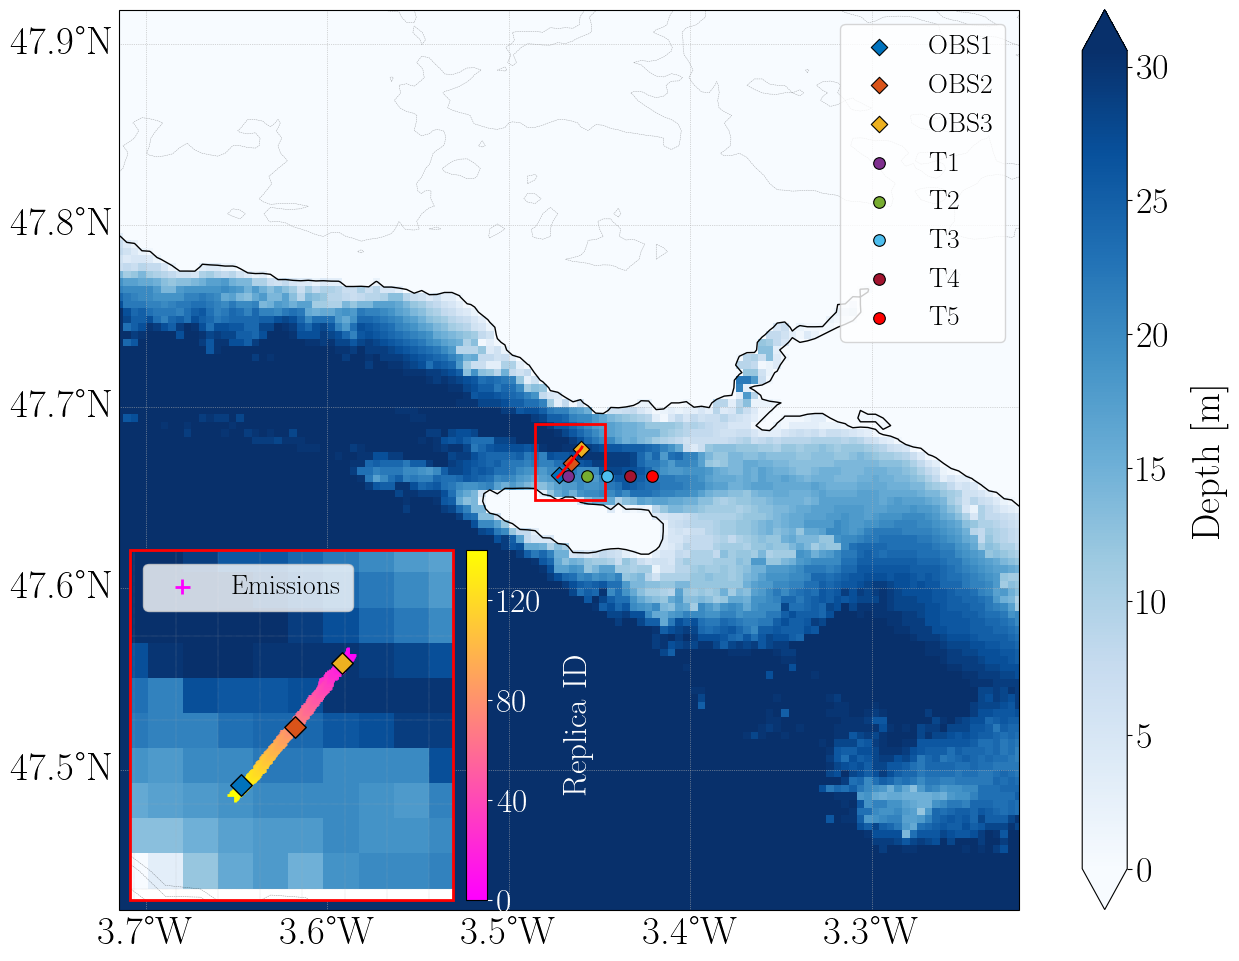

In [17]:
root_img_traj = os.path.join(fig_folder, "trajectory")
os.makedirs(root_img_traj, exist_ok=True)
# plot_seq_replica_positions(df_seq, ds_gps, root_fig=root_img_traj)

plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy, root_img_traj, add_transect_points=True)

### Vitesse du porteur au cours de la trajectoire 

Median source speed along traj : vs = 1.82 m.s-1
Std source speed along traj : vs = 0.35 m.s-1


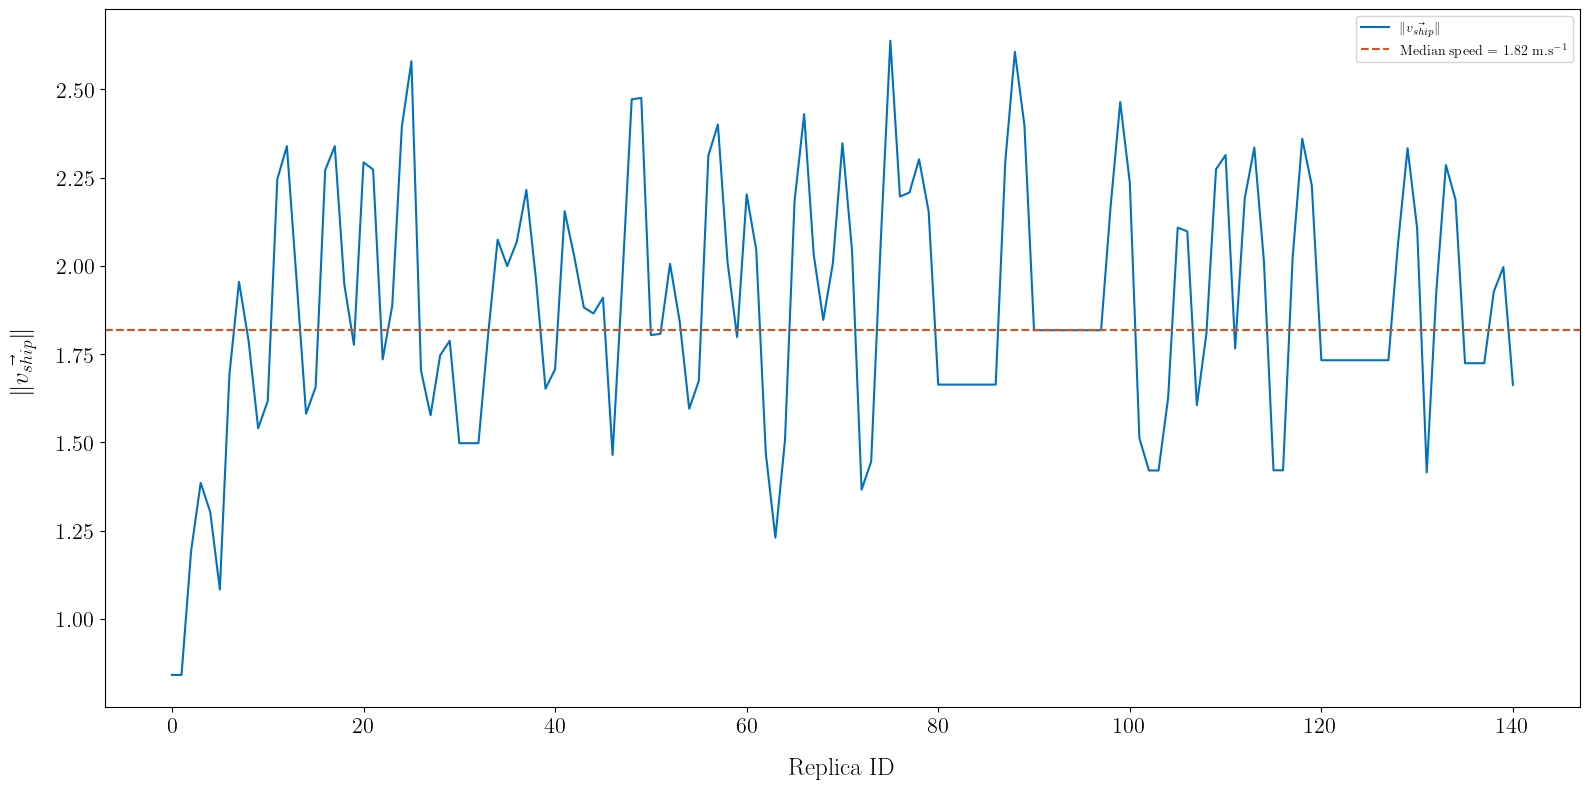

In [18]:
plot_speed_along_seq(df_seq, root_fig=root_img_traj)

### Profondeur de la source 

In [19]:
fpath_rbr = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\RBR\207416_20251016_1535_data.csv"
df_rbr = pd.read_csv(fpath_rbr, header=0, delimiter=",")
# dt_fmt = df_rbr.columns[0].replace("T", " ")
df_rbr["datetime"] = pd.to_datetime(df_rbr[df_rbr.columns[0]])  # Format is explicit 

In [20]:
df_rbr

,yyyy-mm-ddThh:mm:ss.sss,Longitude [degrees_east],Latitude [degrees_north],Bot. Depth [m],Depth [m],Pressure [dbar],Sea pressure [dbar],datetime
0,2025-10-13 12:00:00.000,0.0,0.0,0,0.076754,10.209885,0.077385,2025-10-13 12:00:00
1,2025-10-13 12:00:05.000,0.0,0.0,0,0.077551,10.210689,0.078189,2025-10-13 12:00:05
2,2025-10-13 12:00:10.000,0.0,0.0,0,0.077986,10.211127,0.078627,2025-10-13 12:00:10
3,2025-10-13 12:00:15.000,0.0,0.0,0,0.075014,10.208131,0.075631,2025-10-13 12:00:15
4,2025-10-13 12:00:20.000,0.0,0.0,0,0.078348,10.211492,0.078992,2025-10-13 12:00:20
...,...,...,...,...,...,...,...,...
54412,2025-10-16 15:34:20.000,0.0,0.0,0,0.057677,10.190651,0.058151,2025-10-16 15:34:20
54413,2025-10-16 15:34:25.000,0.0,0.0,0,0.059484,10.192473,0.059973,2025-10-16 15:34:25
54414,2025-10-16 15:34:30.000,0.0,0.0,0,0.058179,10.191158,0.058658,2025-10-16 15:34:30
54415,2025-10-16 15:34:35.000,0.0,0.0,0,0.057817,10.190792,0.058292,2025-10-16 15:34:35


In [21]:
# Slice the required sequence
df_rbr_seq = df_rbr.loc[
    df_rbr["datetime"].between(
        df_seq["emission_datetime"].min(), df_seq["emission_datetime"].max()
    )
]

In [22]:
df_rbr_seq

,yyyy-mm-ddThh:mm:ss.sss,Longitude [degrees_east],Latitude [degrees_north],Bot. Depth [m],Depth [m],Pressure [dbar],Sea pressure [dbar],datetime
51079,2025-10-16 10:56:35.000,0.0,0.0,0,12.098634,22.330605,12.198105,2025-10-16 10:56:35
51080,2025-10-16 10:56:40.000,0.0,0.0,0,12.237494,22.470607,12.338107,2025-10-16 10:56:40
51081,2025-10-16 10:56:45.000,0.0,0.0,0,12.316150,22.549909,12.417409,2025-10-16 10:56:45
51082,2025-10-16 10:56:50.000,0.0,0.0,0,12.137398,22.369688,12.237188,2025-10-16 10:56:50
51083,2025-10-16 10:56:55.000,0.0,0.0,0,11.832969,22.062756,11.930256,2025-10-16 10:56:55
...,...,...,...,...,...,...,...,...
51298,2025-10-16 11:14:50.000,0.0,0.0,0,9.754966,19.967668,9.835168,2025-10-16 11:14:50
51299,2025-10-16 11:14:55.000,0.0,0.0,0,9.792602,20.005613,9.873113,2025-10-16 11:14:55
51300,2025-10-16 11:15:00.000,0.0,0.0,0,9.817276,20.030491,9.897991,2025-10-16 11:15:00
51301,2025-10-16 11:15:05.000,0.0,0.0,0,9.922873,20.136956,10.004456,2025-10-16 11:15:05


Source depth variations during sequence 131:
	Minimum depth: 9.64 m
	Maximum depth: 12.32 m
	Median depth: 9.86 m


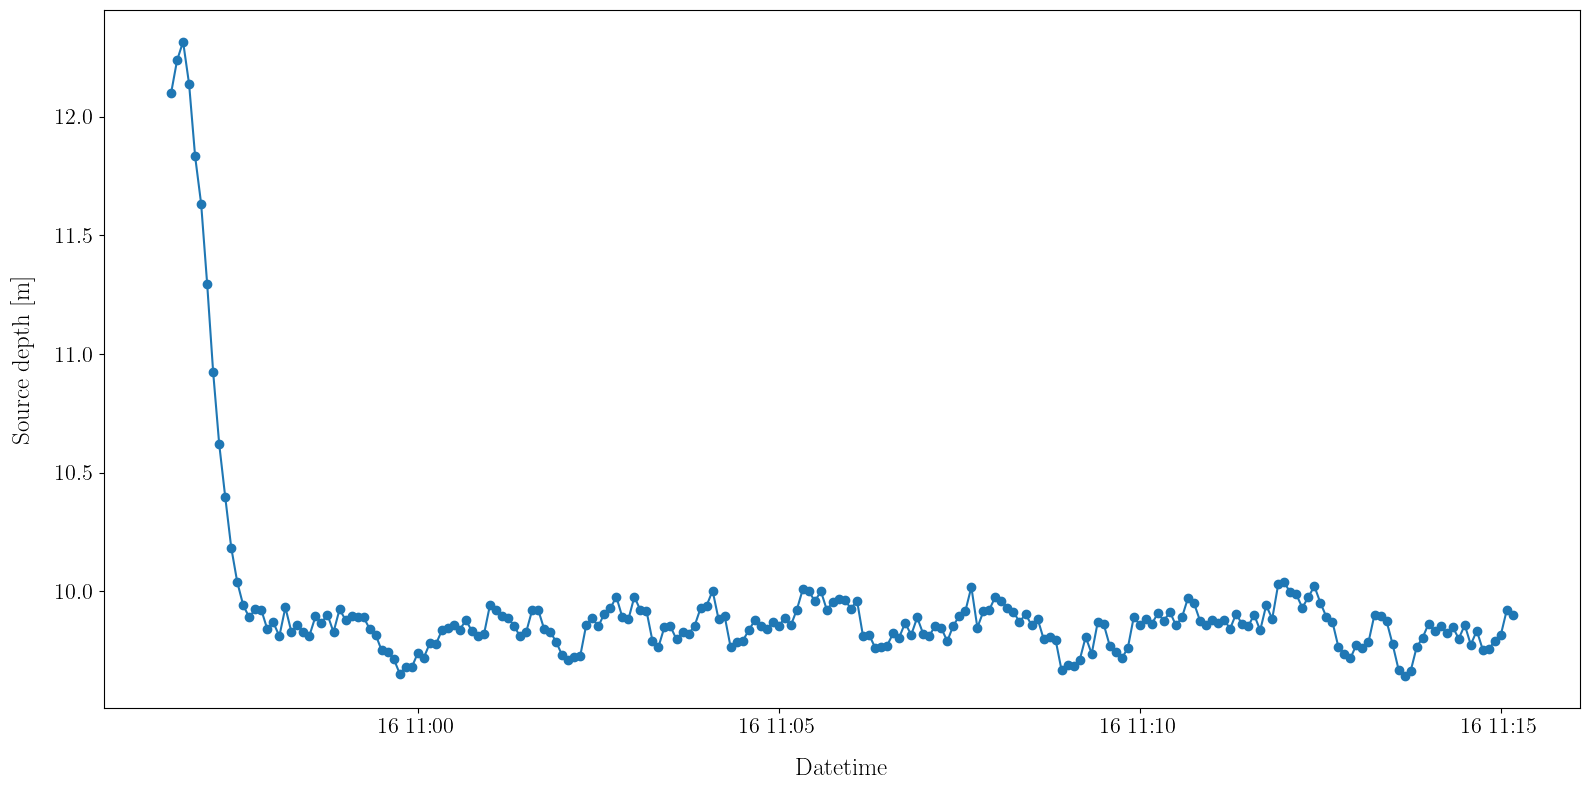

In [23]:
# Plot depth variations along the sequence
plt.figure()
plt.plot(df_rbr_seq["datetime"], df_rbr_seq["Depth [m]"], marker="o")
plt.xlabel("Datetime")
plt.ylabel("Source depth [m]")

print(f"Source depth variations during sequence {seq_id}:")
print(f"\tMinimum depth: {df_rbr_seq['Depth [m]'].min():.2f} m")
print(f"\tMaximum depth: {df_rbr_seq['Depth [m]'].max():.2f} m")
print(f"\tMedian depth: {df_rbr_seq['Depth [m]'].median():.2f} m")

### Données des OBS 

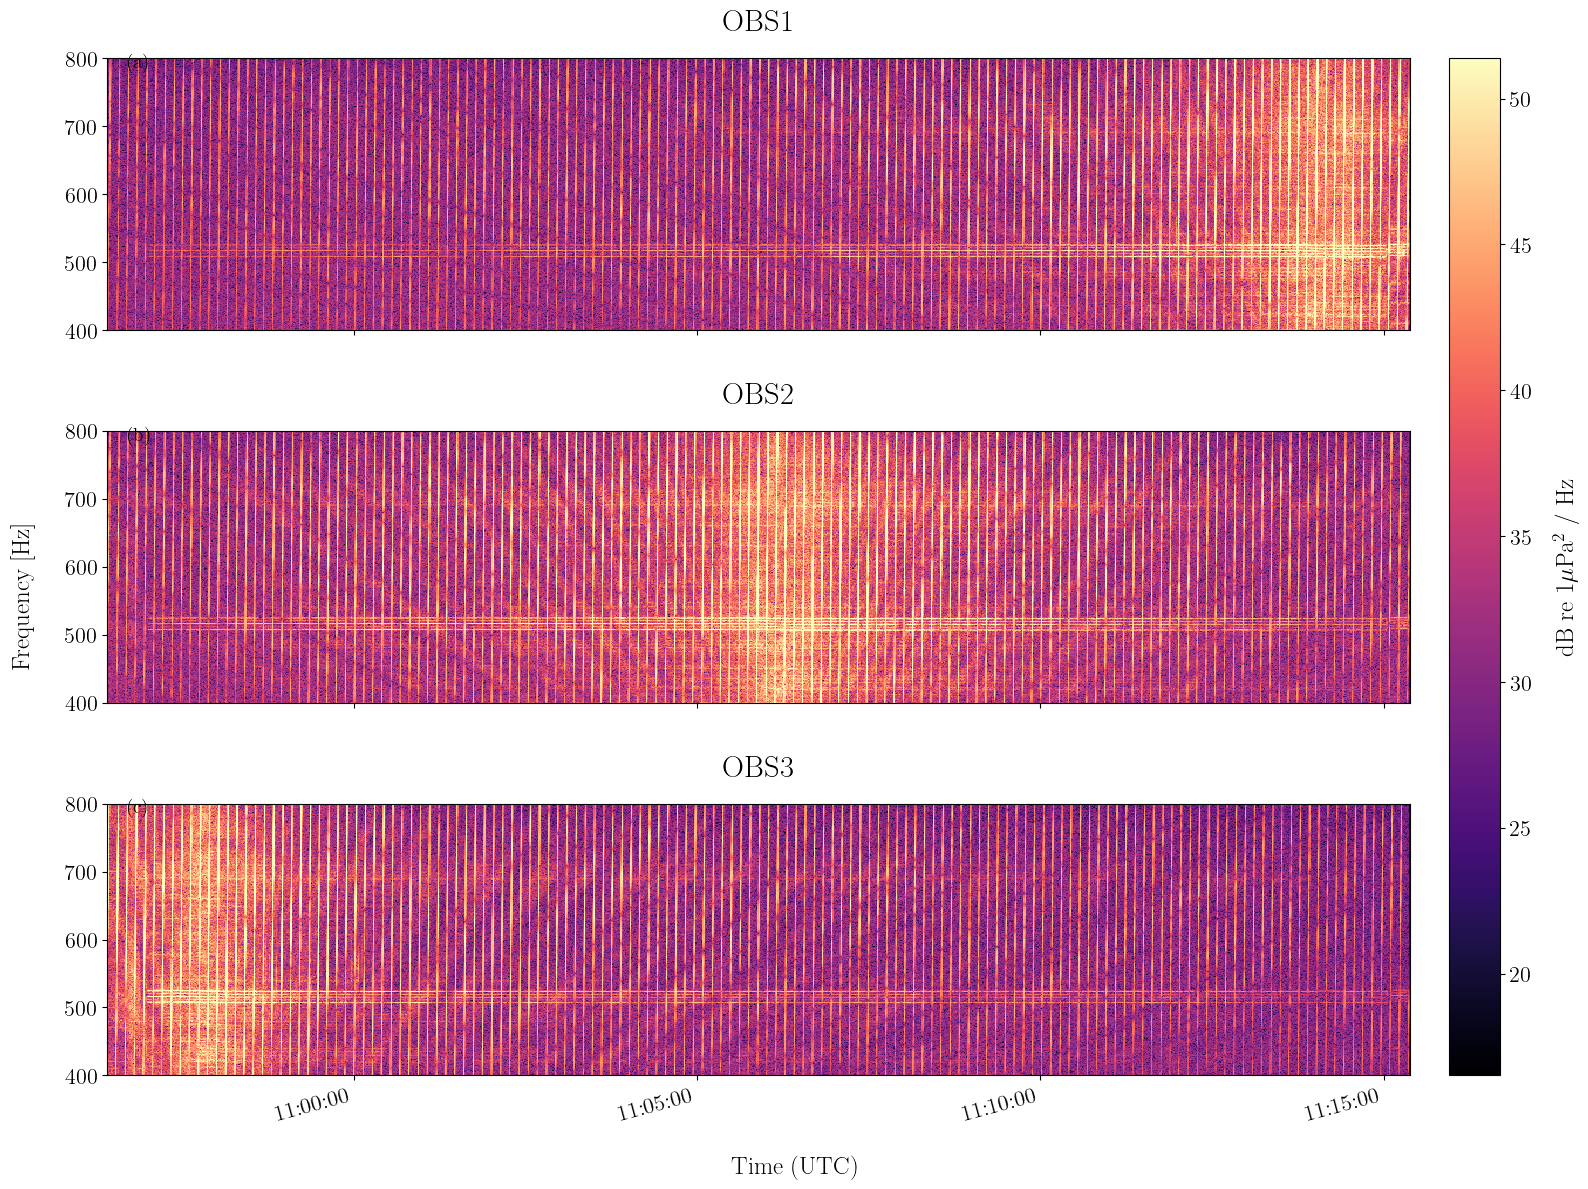

In [24]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

plot_sequence_spectrogram(
    ds_sig,
    ds_wav,
    fig_folder,
    nperseg=2**12,
    noverlap=2**11,
    fmin=fmin,
    fmax=fmax,
    fname="sequence_signal_spectrogram.png",
)

On peut clairement distinguer le passage du porteur au CPA des trois OBS au cours de la trajectoire. 

Compute distance using euclidian angle between RTF modules (in R^Nrcv)
	Plotting RTF distance vs spatial distance
	Plotting RTF distance vs spatial distance (sorted by distance)


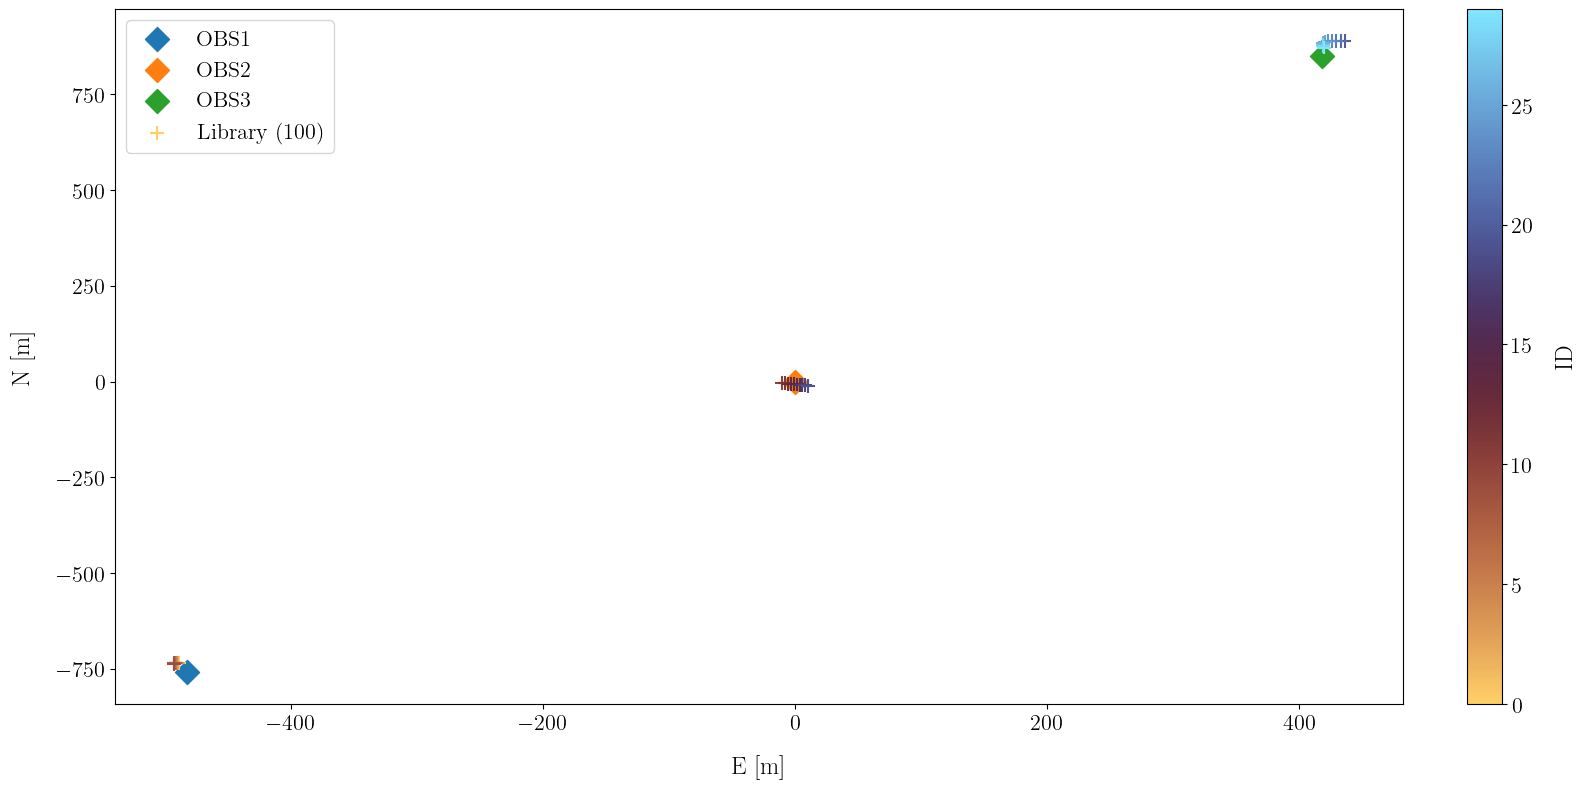

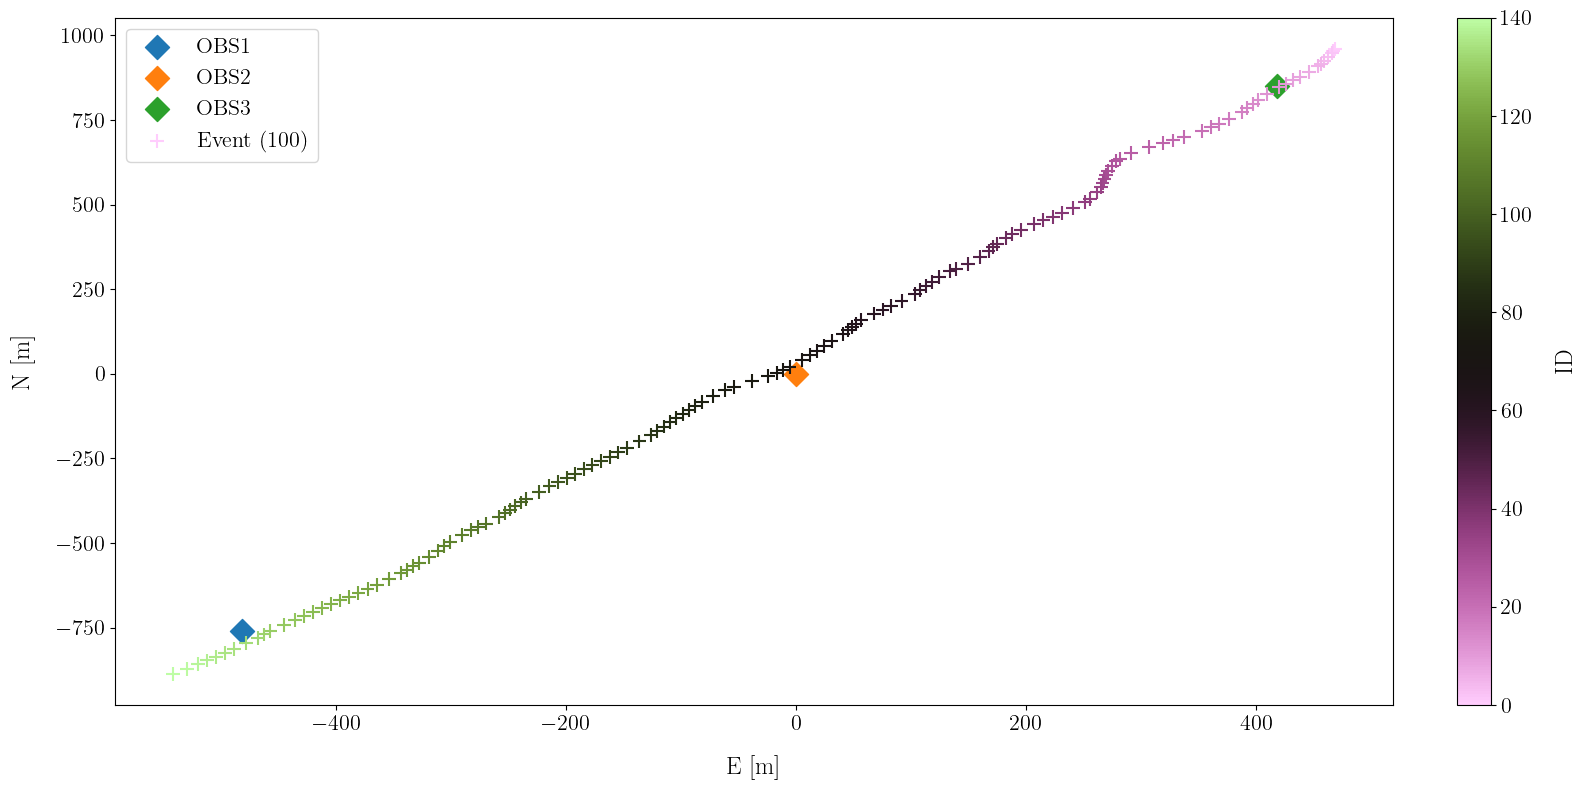

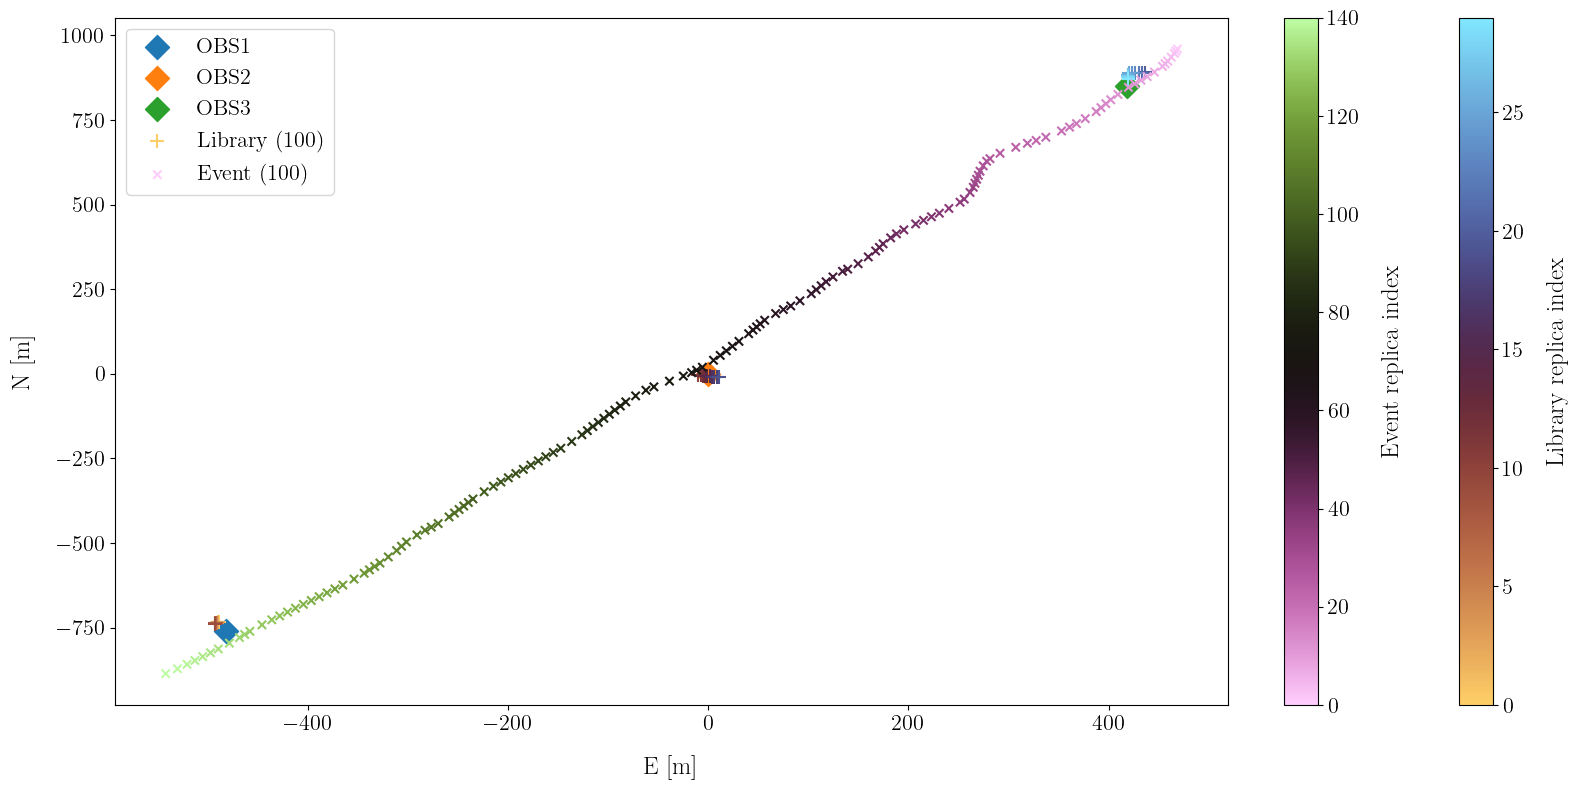

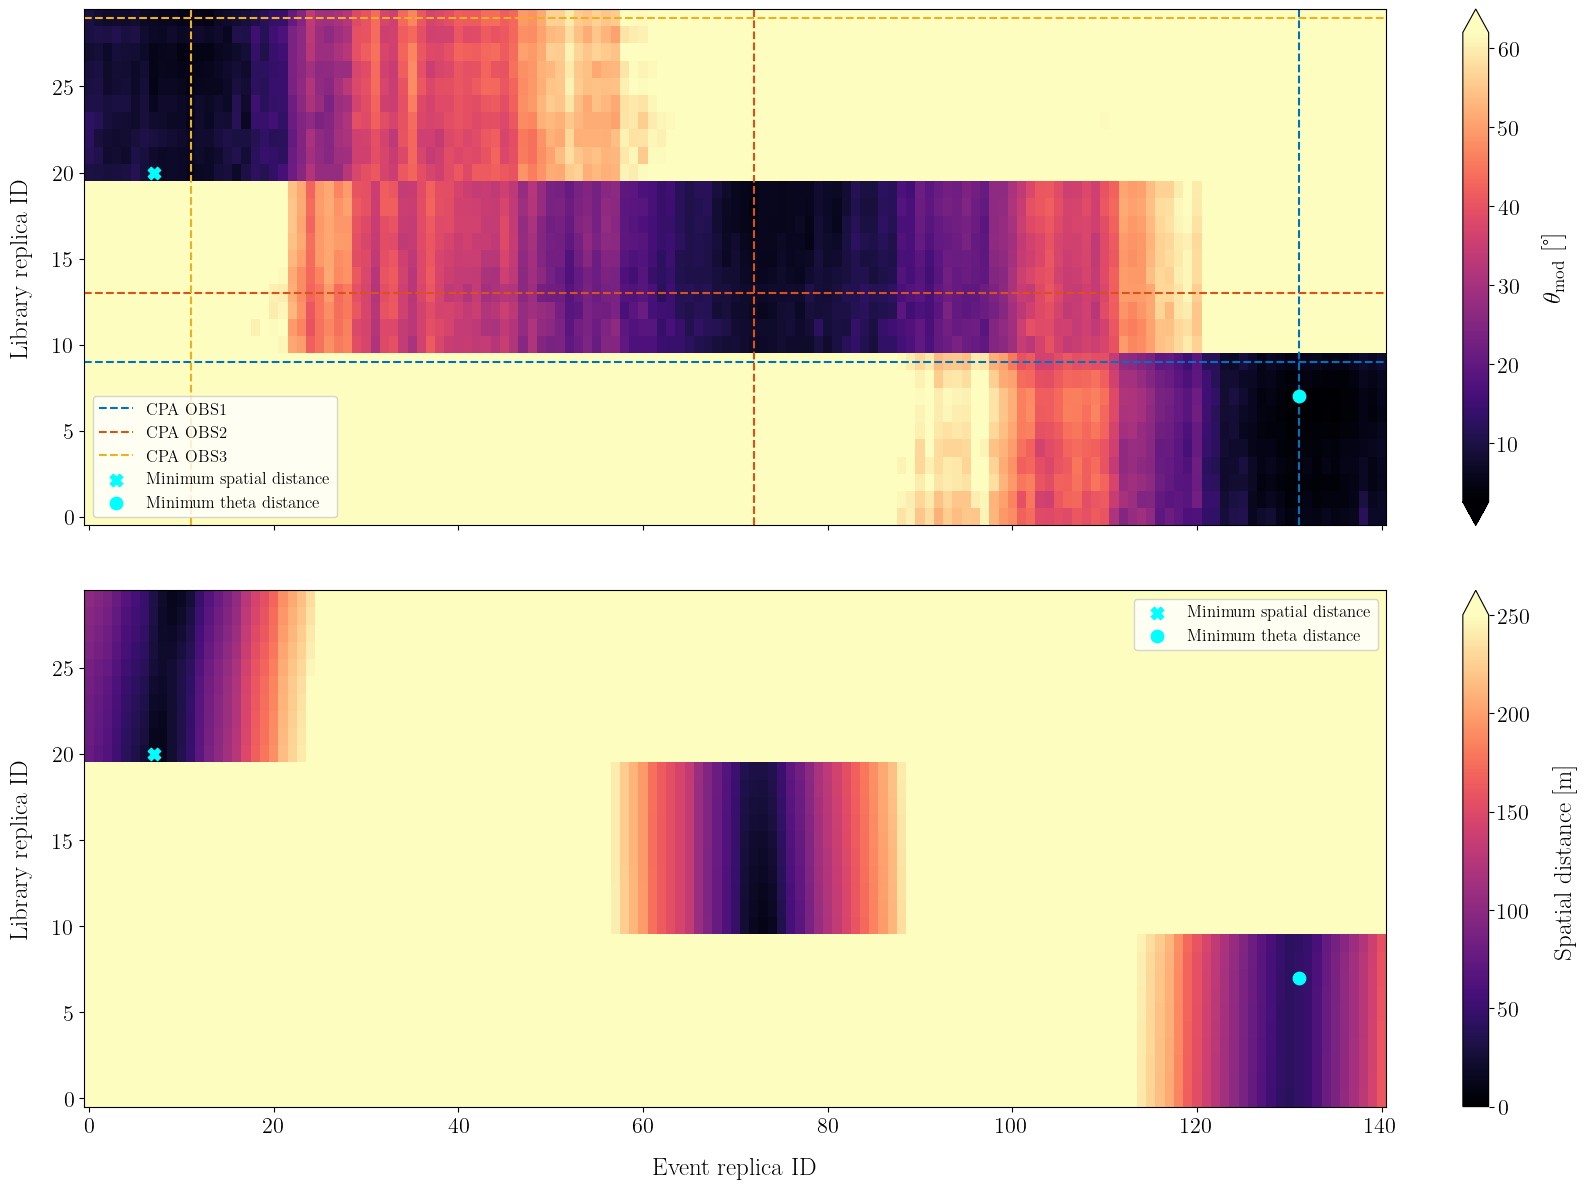

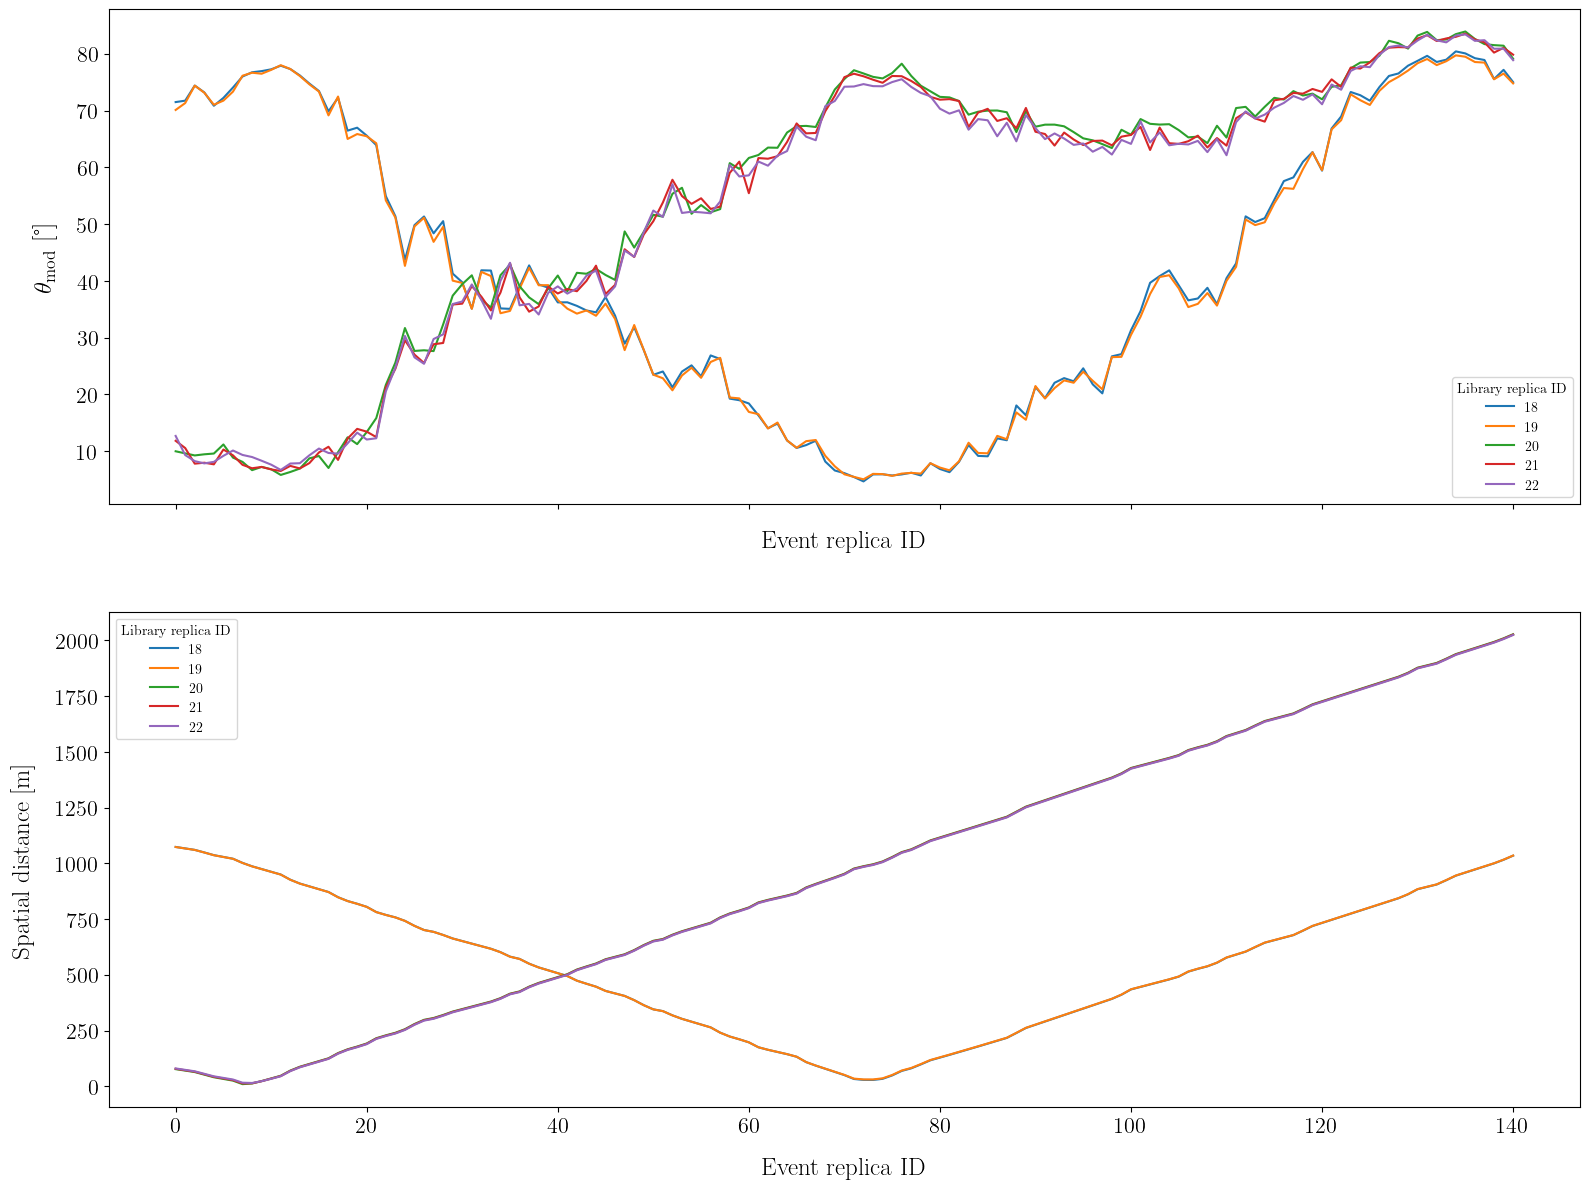

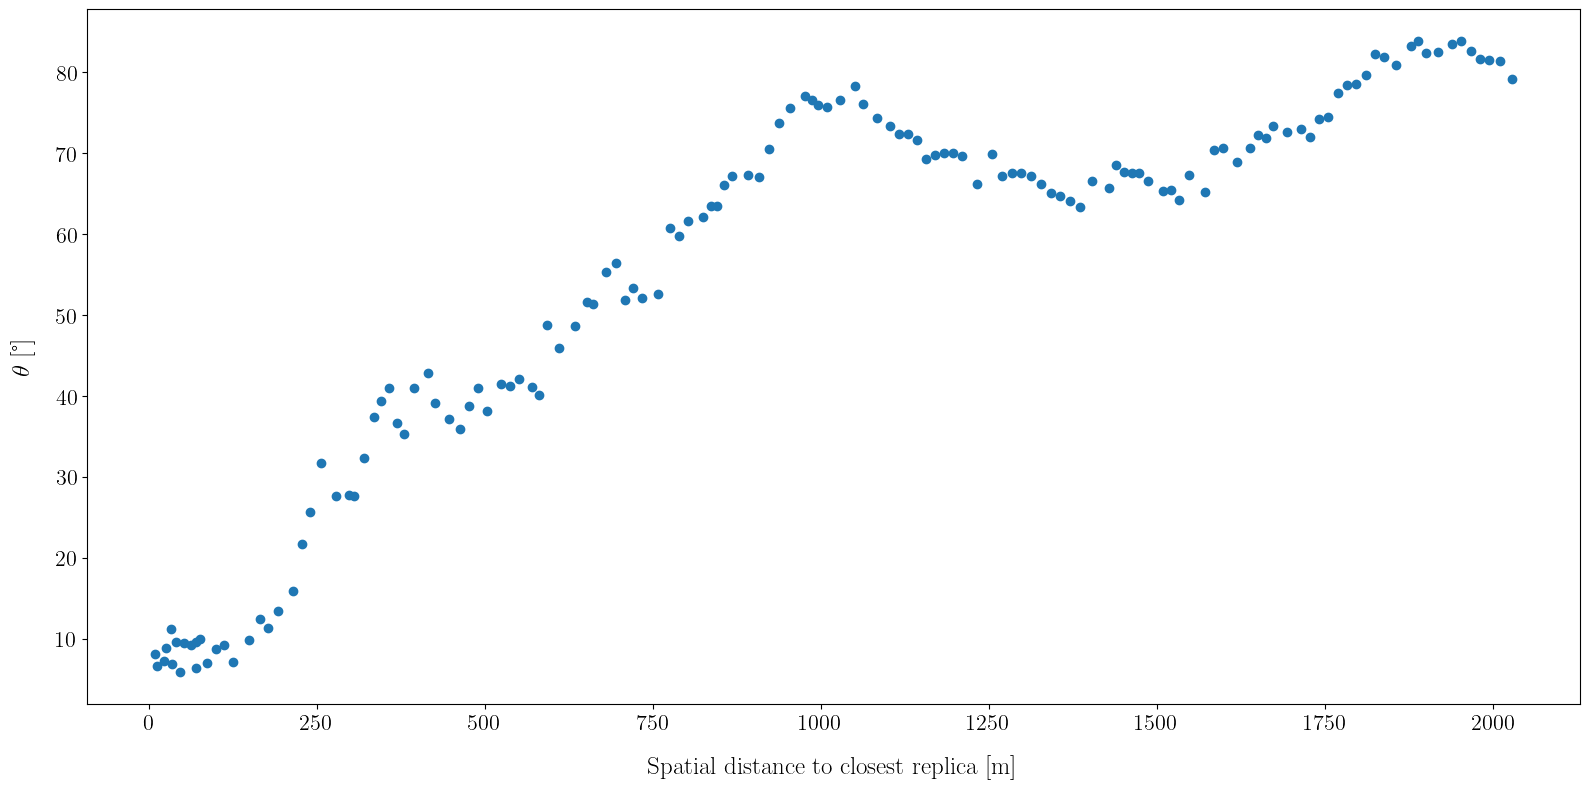

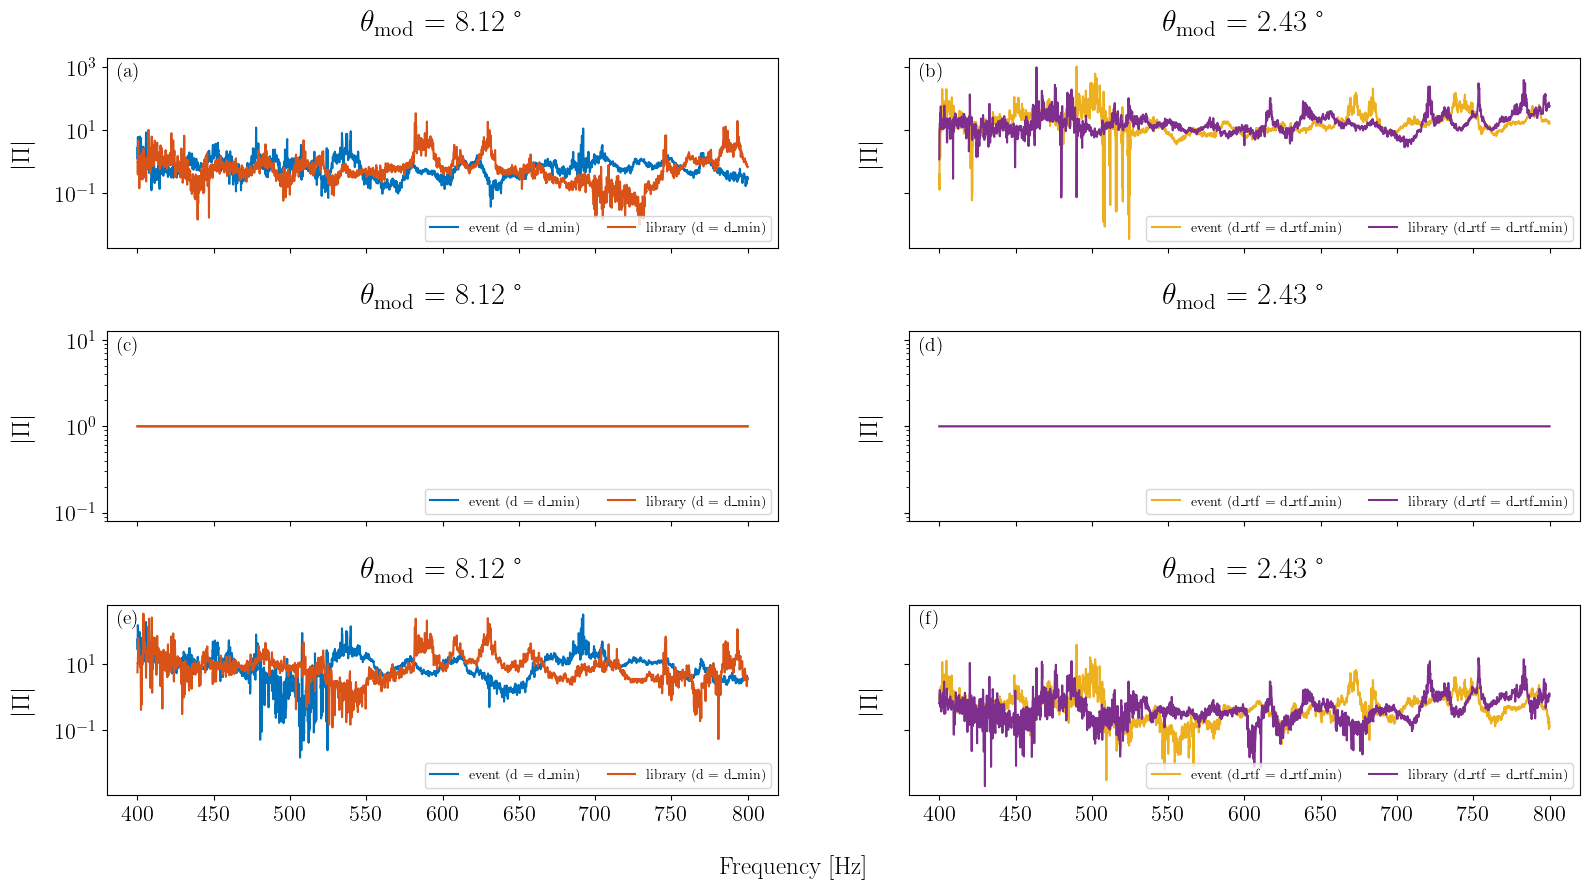

In [25]:
dist_args = {
    "fmin": fmin,
    "fmax": fmax,
    # "dist_type": "hermitian_angle",
    "dist_type": "hermitian_angle_module",
    "use_weighted_mean": False,
}
ds_results = rtf_mfp_processor.match(
    id_library=id_library, id_event=id_event, dist_args=dist_args
)


Position OBS1 - RTF distance: median=3.60, min=2.43, max=4.71
Position OBS2 - RTF distance: median=6.08, min=4.69, max=7.37
Position OBS3 - RTF distance: median=5.72, min=4.64, max=7.04


Text(0.5, 0.01, 'ID')

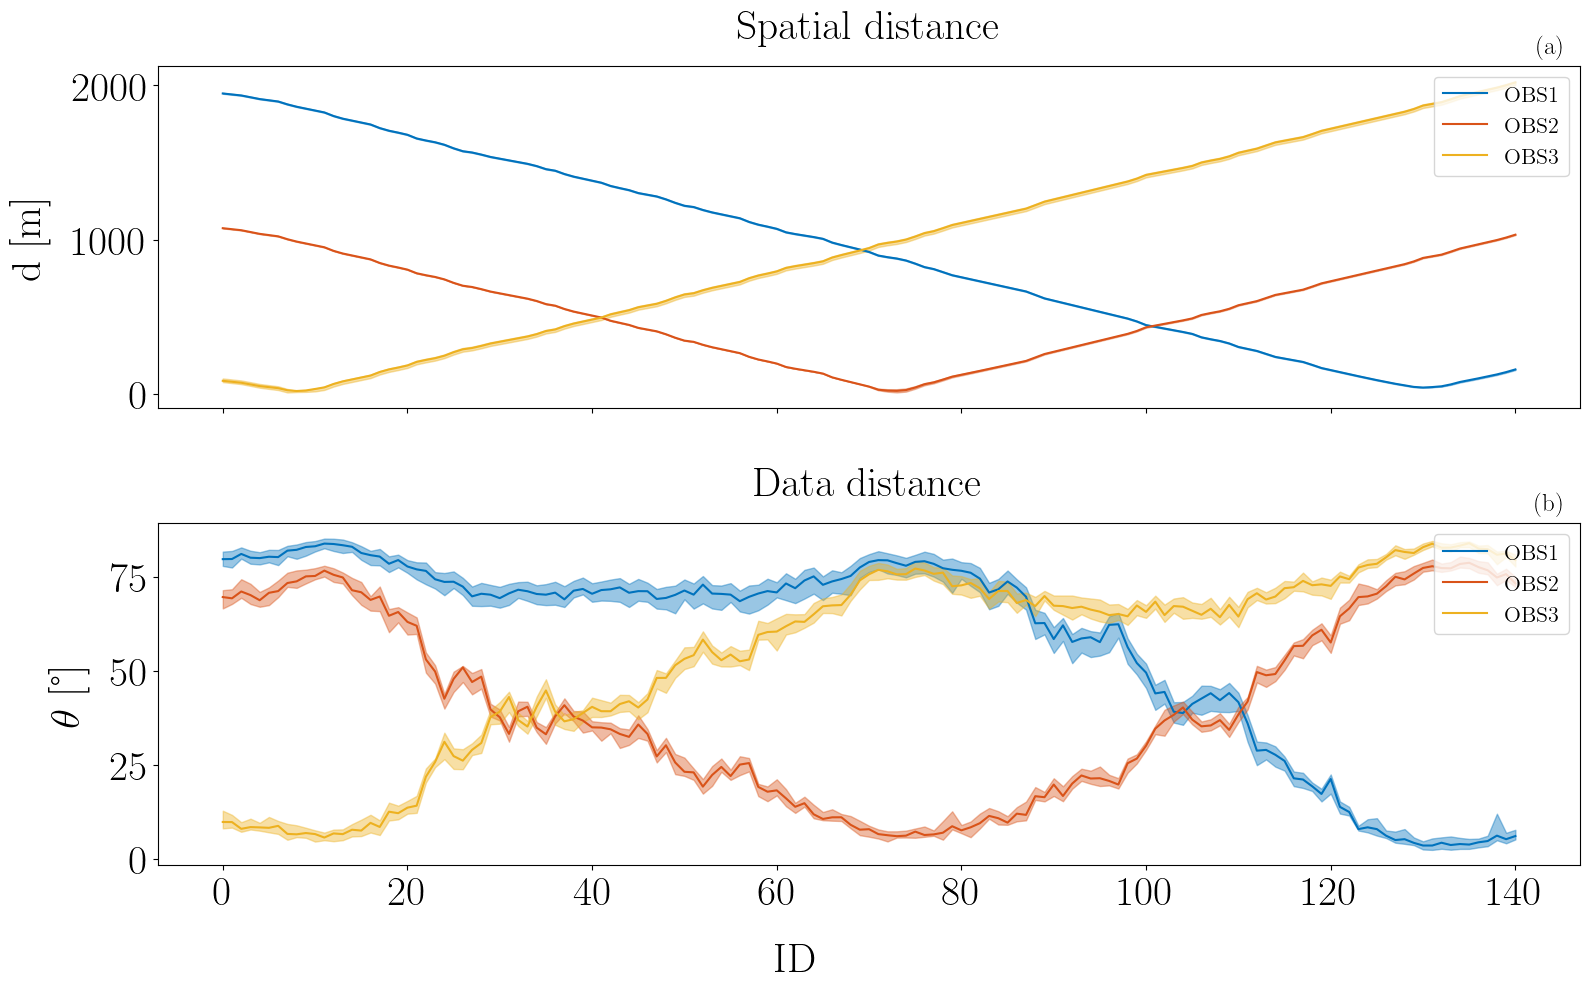

In [26]:
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)

fig, axs = plt.subplots(2, 1, sharex=True)
# fig.suptitle(f"Event {event_seq_id} (trailed)")
rep_sel = [0, 10, 20]
rep_sel_pos = ["OBS1", "OBS2", "OBS3"]

ds_res_sel = ds_results.sel(event_replica_id=rep_sel)

for i, pos in enumerate(rep_sel_pos):

    # Select ipos

    # Event is static pos
    # ds_res_sel = ds_results.sel(event_replica_id=slice(i*10,(i+1)*10 - 1))
    # dim = "event_replica_id"
    # dim_bis = "library_replica_id"

    # Event is towed source
    ds_res_sel = ds_results.sel(library_replica_id=slice(i*10,(i+1)*10 - 1))
    dim = "library_replica_id"
    dim_bis = "event_replica_id"

    rtf_dist_median = ds_res_sel.rtf_dist.median(dim=dim)
    rtf_dist_min = ds_res_sel.rtf_dist.min(dim=dim)
    rtf_dist_max = ds_res_sel.rtf_dist.max(dim=dim)
    spatial_dist_median = ds_res_sel.spatial_dist.median(dim=dim)
    spatial_dist_min = ds_res_sel.spatial_dist.min(dim=dim)
    spatial_dist_max = ds_res_sel.spatial_dist.max(dim=dim)

    rtf_dist_median.plot(label=pos, ax=axs[1], color=color(i))
    axs[1].fill_between(
        ds_results[dim_bis].values,
        rtf_dist_min.values,
        rtf_dist_max.values,
        color=color(i),
        alpha=0.4,
        # label="$\mu \pm \sigma$",
    )

    print(f"Position {pos} - RTF distance: median={rtf_dist_median.min().values:.2f}, min={rtf_dist_min.min().values:.2f}, max={rtf_dist_max.min().values:.2f}")

    spatial_dist_median.plot(label=pos, ax=axs[0], color=color(i))
    axs[0].fill_between(
        ds_results[dim_bis].values,
        spatial_dist_min.values,
        spatial_dist_max.values,
        color=color(i),
        alpha=0.4,
        # label="$\mu \pm \sigma$",
    )


axs[0].legend(ncol=1, loc="upper right", fontsize=16)
axs[0].set_ylabel("d [m]")
axs[0].set_xlabel("")
axs[0].set_title("")

axs[1].legend(ncol=1, loc="upper right", fontsize=16)
axs[1].set_ylabel(r"$\theta$ [°]")
axs[1].set_xlabel("")
axs[1].set_title("")

axs[0].set_title("Spatial distance")
axs[1].set_title("Data distance")

# Subfigure annotations

# # Subfigure annotations
# axs[1].text(
#     0.01,
#     0.95,
#     "(a)",
#     transform=axs[1].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     va="top",
# )

# axs[0].text(
#     0.01,
#     0.95,
#     "(b)",
#     transform=axs[1].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     va="top",
# )
set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.99, y_pos=1.02, ha="right", va="bottom"
)

fig.supxlabel("ID")


# fpath = os.path.join(root_fig, "theta_and_dist_vs_time.png")
# plt.savefig(fpath)

*2m*

* Position OBS1 - RTF distance: median=6.48, min=5.36, max=7.45
* Position OBS2 - RTF distance: median=12.84, min=9.39, max=14.76 (5m)
* Position OBS3 - RTF distance: median=11.54, min=8.37, max=12.94

*5m* 
* Position OBS1 - RTF distance: median=8.01, min=5.37, max=9.60
* Position OBS2 - RTF distance: median=12.84, min=9.39, max=14.76
* Position OBS3 - RTF distance: median=12.12, min=9.82, max=14.31

*8m*
* Position OBS1 - RTF distance: median=6.43, min=5.61, max=7.36
* Position OBS2 - RTF distance: median=12.84, min=9.39, max=14.76 (5m)
* Position OBS3 - RTF distance: median=15.33, min=14.26, max=16.27

# Allure du vecteur de RTF 

In [27]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event\event_100.nc"
ds_event = xr.open_dataset(fpath)

In [28]:
dist_rcv = get_dist_to_rcv(ds_event)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds_event.replica_id.values

In [29]:
print(f"Closest approach for each OBS:")
print(f"\tOBS1: replica {reps[obs_cpa_idx[0]]}, distance = {dist_rcv[0, obs_cpa_idx[0], 0]:.2f} m")
print(f"\tOBS2: replica {reps[obs_cpa_idx[1]]}, distance = {dist_rcv[1, obs_cpa_idx[1], 0]:.2f} m")
print(f"\tOBS3: replica {reps[obs_cpa_idx[2]]}, distance = {dist_rcv[2, obs_cpa_idx[2], 0]:.2f} m")


Closest approach for each OBS:
	OBS1: replica 131, distance = 22.00 m
	OBS2: replica 72, distance = 15.72 m
	OBS3: replica 11, distance = 4.53 m


(<Figure size 1600x1000 with 4 Axes>,
 array([<Axes: title={'center': 'OBS 1'}>,
        <Axes: title={'center': 'OBS 3'}>], dtype=object))

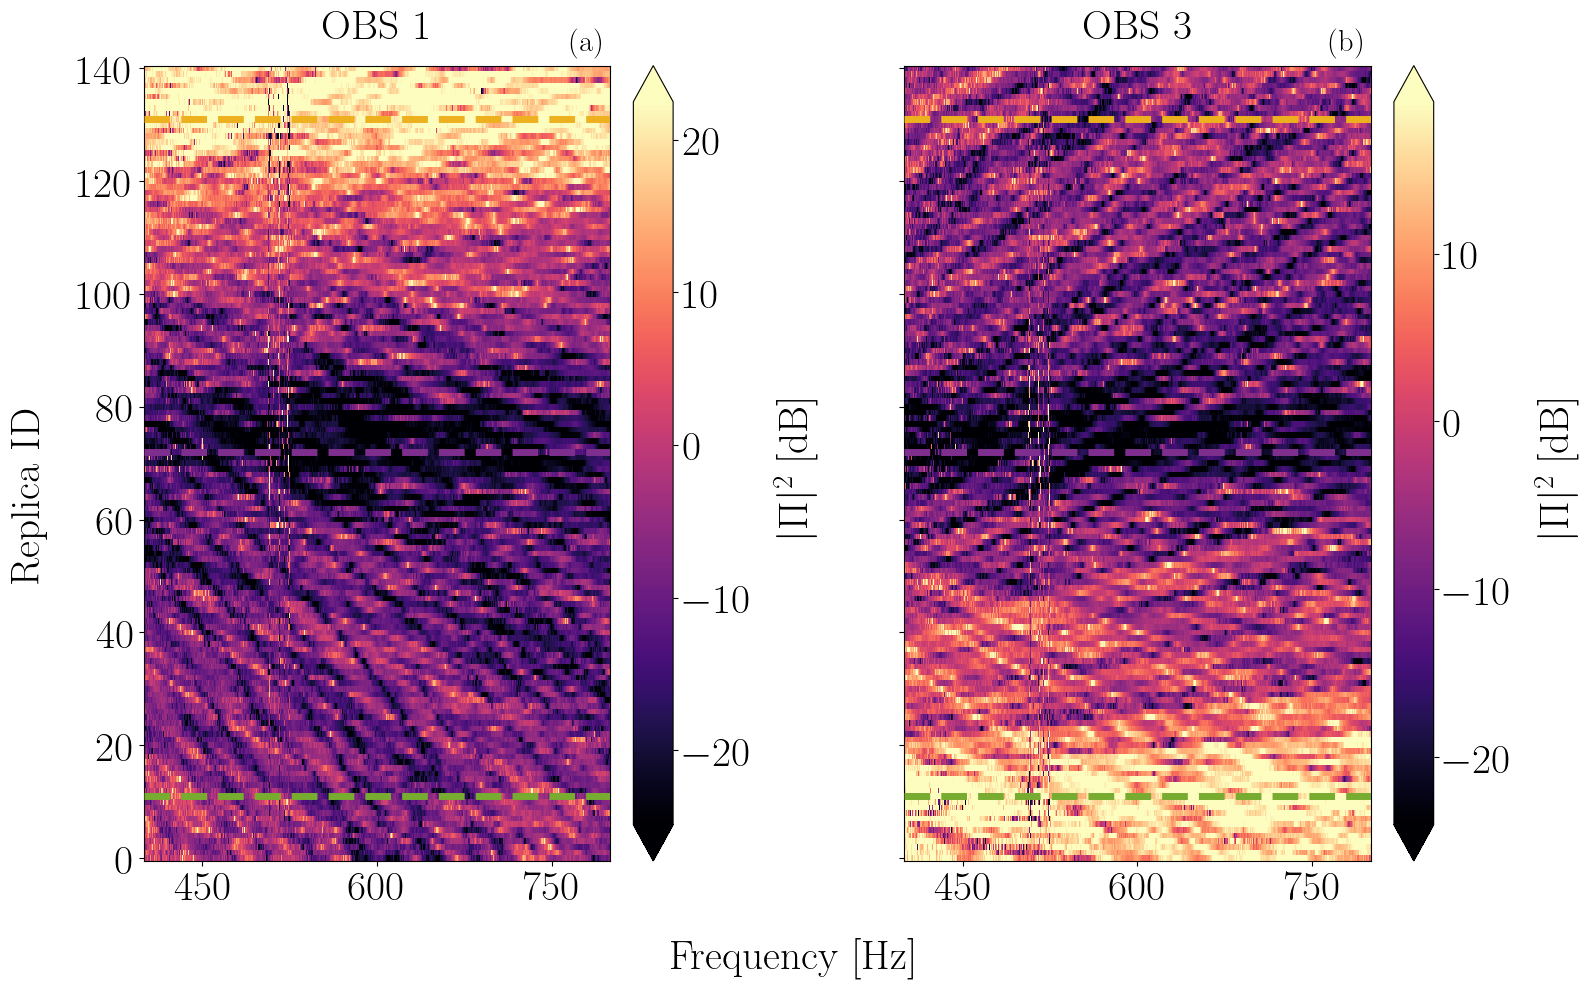

In [30]:
plot_gamma_along_sequence(
    ds_event,
    dist_rcv,
    obs_cpa_idx,
    reps,
    fig_folder=fig_folder,
    replica_id_slice=slice(0, 500),
    fmin=fmin,
    fmax=fmax,
    fname="rtf_mod_along_sequence.png",
)

## Application Diffusion Map

On considère une des composantes du vecteur de RTF. 

Le choix des paramètres K, et $\epsilon$ suit la stratégie de Laufer-Goldenstein et al. 2016 :

* K est fixé au nombre de point total du dataset : pas de coupure du noyau gaussien 
* $\epsilon$ est fixé à une valeur proportionnelle à la distance médiane entre tous les points du dataset. 

La dimension réduite $d$ est fixée par analyse des valeurs propres. 

In [ ]:
# from pydiffmap import diffusion_map as dm

# # initialize Diffusion map object.
# neighbor_params = {"n_jobs": -1, "algorithm": "ball_tree"}

In [ ]:
# ds_event

In [ ]:
# seletected_obs = 1
# X = ds_event.rtf_amp.sel(h_index=seletected_obs)
# X

### Etape 1 : analyse de la distribution des valeurs propres 

In [ ]:
# d = X.sizes["replica_id"] - 3
# d

In [ ]:
# k = X.sizes["replica_id"]
# k

In [ ]:
# mydmap = dm.DiffusionMap.from_sklearn(
#     n_evecs=d, k=k, epsilon="bgh", alpha=1.0, neighbor_params=neighbor_params
# )

In [ ]:
# X_in = X.values
# X_in

In [ ]:
# # # fit to data and return the diffusion map.
# X_diffmap = mydmap.fit_transform(X_in)

In [ ]:
# X_diffmap.shape  # -> (n_pos, d)

In [ ]:
# # Plot data in the diffusion embedding and isomap embedding
# X_isomap = X_isomap_dict["mod"]["X_isomap"]
# X_isomap_data = X_isomap[:-1, :].T

# fig, ax = plt.subplots(1, 1)
# ax.plot(r_grid_km, X_isomap_data[0, :], color=color(0))
# ax.set_ylabel(r"$\Psi_1^{\text{Isomap}}$")

# # Duplicate axis to plot diffusion embedding
# ax2 = ax.twinx()
# ax2.plot(r_grid_km, X_diffmap_data[0, :], color=color(1))
# ax2.set_ylabel(r"$\Psi_1^{\text{Diffusion}}$")
# ax.yaxis.label.set_color(color(0))
# ax2.yaxis.label.set_color(color(1))
# ax.tick_params(axis="y", colors=color(0))
# ax2.tick_params(axis="y", colors=color(1))
# ax.set_xlabel("Range [km]")

# # Save figure
# fname = f"embedding_isomap_diffusion_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
# fpath = os.path.join(img_dir, fname)
# plt.savefig(fpath, dpi=300)